In [1]:
import numpy as np

In [2]:
def create_binary_dataset(start=0, end=10, bit_width=4):
    X = []
    y = []

    for value in range(start, end + 1):
        bits = [int(bit) for bit in format(value, f"0{bit_width}b")]
        target = 0 if value < 8 else 1

        X.append(bits)
        y.append([target])

    return np.array(X, dtype=float), np.array(y, dtype=float)

In [3]:
def train_test_split(X, y, train_ratio=0.7, seed=None):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(X))
    train_count = round(train_ratio * len(X))

    train_indices = indices[:train_count]
    test_indices = indices[train_count:]

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

In [4]:
class BackPropagationNetwork:
    def __init__(
        self,
        input_size,
        hidden_size,
        output_size,
        learning_rate=0.5,
        error_limit=0.01,
        max_iterations=100000,
        seed=None,
    ):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.error_limit = error_limit
        self.max_iterations = max_iterations

        rng = np.random.default_rng(seed)
        self.hidden_weights = rng.uniform(-1.0, 1.0, (input_size, hidden_size))
        self.output_weights = rng.uniform(-1.0, 1.0, (hidden_size, output_size))

        self.hidden_thresholds = rng.uniform(-1.0, 1.0, (1, hidden_size))
        self.output_thresholds = rng.uniform(-1.0, 1.0, (1, output_size))

        self.iterations = 0
        self.error_history = []

    def threshold_function(self, net_input):
        return 1.0 / (1.0 + np.exp(-net_input))

    def threshold_derivative(self, output):
        return output * (1.0 - output)

    def forward(self, X):
        self.hidden_net = np.dot(X, self.hidden_weights) - self.hidden_thresholds
        self.hidden_output = self.threshold_function(self.hidden_net)

        self.output_net = np.dot(self.hidden_output, self.output_weights) - self.output_thresholds
        self.final_output = self.threshold_function(self.output_net)

        return self.final_output

    def total_error(self, y_true, y_pred):
        return 0.5 * np.mean((y_true - y_pred) ** 2)

    def backward(self, X, y_true):
        n_samples = X.shape[0]

        output_error = y_true - self.final_output
        output_delta = output_error * self.threshold_derivative(self.final_output)

        hidden_error = np.dot(output_delta, self.output_weights.T)
        hidden_delta = hidden_error * self.threshold_derivative(self.hidden_output)

        self.output_weights += (
            self.learning_rate * np.dot(self.hidden_output.T, output_delta) / n_samples
        )
        self.hidden_weights += (
            self.learning_rate * np.dot(X.T, hidden_delta) / n_samples
        )

        self.output_thresholds -= (
            self.learning_rate * np.mean(output_delta, axis=0, keepdims=True)
        )
        self.hidden_thresholds -= (
            self.learning_rate * np.mean(hidden_delta, axis=0, keepdims=True)
        )

    def fit(self, X, y, print_every=1000):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        if y.ndim == 1:
            y = y.reshape(-1, 1)

        self.error_history = []
        self.iterations = 0

        error = float("inf")

        while error > self.error_limit and self.iterations < self.max_iterations:
            y_pred = self.forward(X)
            error = self.total_error(y, y_pred)
            self.error_history.append(error)

            self.backward(X, y)
            self.iterations += 1

            if print_every and (self.iterations == 1 or self.iterations % print_every == 0):
                print(f"Iteration {self.iterations:6d} | Error: {error:.8f}")

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        return self.forward(X)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

In [5]:
X, y = create_binary_dataset(start=0, end=10, bit_width=4)

print("Input data:")
print(X.astype(int))

print("\nTarget output:")
print(y.astype(int))

Input data:
[[0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 1 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 0 0]
 [1 0 0 1]
 [1 0 1 0]]

Target output:
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_ratio=0.7, seed=7)

print("Training data:")
for inputs, target in zip(X_train.astype(int), y_train.astype(int)):
    print(f"{inputs.tolist()} -> {target[0]}")

print("\nTesting data:")
for inputs, target in zip(X_test.astype(int), y_test.astype(int)):
    print(f"{inputs.tolist()} -> {target[0]}")

Training data:
[0, 1, 0, 0] -> 0
[0, 1, 1, 0] -> 0
[1, 0, 1, 0] -> 1
[0, 0, 0, 0] -> 0
[0, 0, 0, 1] -> 0
[0, 0, 1, 1] -> 0
[1, 0, 0, 0] -> 1
[0, 1, 1, 1] -> 0

Testing data:
[0, 0, 1, 0] -> 0
[0, 1, 0, 1] -> 0
[1, 0, 0, 1] -> 1


In [7]:
model = BackPropagationNetwork(
    input_size=4,
    hidden_size=4,
    output_size=1,
    learning_rate=1.0,
    error_limit=0.001,
    max_iterations=100000,
    seed=7,
)

In [8]:
model.fit(X_train, y_train, print_every=1000)

Iteration      1 | Error: 0.33131572
Iteration   1000 | Error: 0.00112110


In [9]:
print("Hidden thresholds:")
print(np.round(model.hidden_thresholds, 4))

print("\nOutput thresholds:")
print(np.round(model.output_thresholds, 4))

print(f"\nTraining stopped after {model.iterations} iterations")
print(f"Final error: {model.error_history[-1]:.8f}")

Hidden thresholds:
[[ 0.6051 -0.7555  0.5485 -1.2308]]

Output thresholds:
[[1.1018]]

Training stopped after 1080 iterations
Final error: 0.00099871


In [10]:
train_predictions = model.predict(X_train)

print("Training predictions:")
for inputs, target, prediction in zip(X_train.astype(int), y_train.astype(int), train_predictions):
    print(f"{inputs.tolist()} -> target={target[0]}, class={prediction[0]}")

Training predictions:
[0, 1, 0, 0] -> target=0, class=0
[0, 1, 1, 0] -> target=0, class=0
[1, 0, 1, 0] -> target=1, class=1
[0, 0, 0, 0] -> target=0, class=0
[0, 0, 0, 1] -> target=0, class=0
[0, 0, 1, 1] -> target=0, class=0
[1, 0, 0, 0] -> target=1, class=1
[0, 1, 1, 1] -> target=0, class=0


In [11]:
test_probabilities = model.predict_proba(X_test)
test_predictions = model.predict(X_test)
test_accuracy = np.mean(test_predictions == y_test.astype(int)) * 100

print("Testing predictions:")
for inputs, target, probability, prediction in zip(
    X_test.astype(int), y_test.astype(int), test_probabilities, test_predictions
):
    print(
        f"{inputs.tolist()} -> target={target[0]}, "
        f"probability={probability[0]:.4f}, "
        f"class={prediction[0]}"
    )

print(f"\nTest accuracy: {test_accuracy:.2f}%")

Testing predictions:
[0, 0, 1, 0] -> target=0, probability=0.1423, class=0
[0, 1, 0, 1] -> target=0, probability=0.0076, class=0
[1, 0, 0, 1] -> target=1, probability=0.6934, class=1

Test accuracy: 100.00%


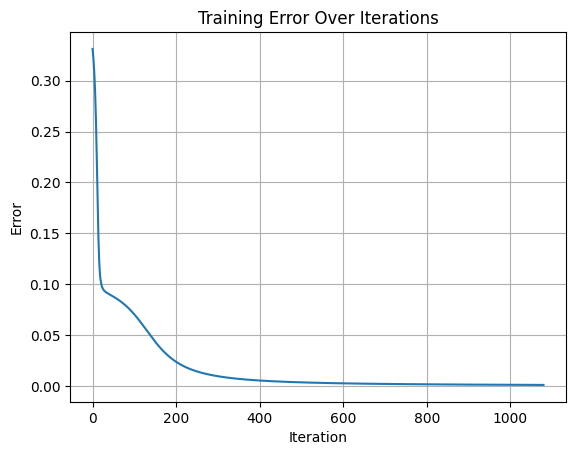

In [12]:
import matplotlib.pyplot as plt

plt.plot(model.error_history)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Training Error Over Iterations")
plt.grid(True)
plt.show()